# Lectura de datos 

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from natsort import natsorted

def ReadCSVData(path):
		### Carga los datos limpios desde el csv 
		### Salta las primeras 16 lineas, usa solo una columna, 
		### remplaza los posibles errores NULL por el valor nan y los quita
		### Guarda los datos en un array 1D para operarlos
		dataCSV = pd.read_csv(path+file, delimiter=',', skiprows=16, usecols=range(1)).replace('Null', np.nan).dropna()
		data = dataCSV.to_numpy(dtype=int).reshape(-1)
	
		
		### Datos de configuración del osciloscopio
		### lee los primeros 15 datos a dos columnas, obtiene el nombre de las columnas y 
		### los sustituye por DATO y VALOR para que sea mas legible el DF
		config = pd.read_csv(path+file, delimiter=',',nrows=15 ,usecols=range(2))
		colNames = config.columns.tolist()
		config = config.rename(columns={colNames[0]:'DATO', colNames[1]:'VALOR'})
		
		### Busca y obtiene los datos necesarios para la config de la escala vertical y horizontal
		vscale = float(config.loc[config['DATO'] == 'Vertical Scale', 'VALOR'].values[0])
		sampling = float(config.loc[config['DATO'] == 'Sampling Period', 'VALOR'].values[0])
		offset = float(config.loc[config['DATO'] == 'Vertical Position', 'VALOR'].values[0])
		# source = config.loc[config['DATO'] == 'Source', 'VALOR'].values[0]

		return [sampling, vscale, offset], data


path= ".\\datos\\"
fullData = {}

# print(os.listdir(path=path))


### Barrido de todos los CSV de la carpeta
for file in natsorted(os.listdir(path=path)):
	config, data = ReadCSVData(path)

	### Escala los datos dada la config del osciloscopio y crea la escala temporal
	data = ((data/25) + config[2]) * config[1]
	t = np.arange(len(data)) * config[0]

	### Empaqueta los datos escalados junto con su escala de tiempo y 
	### los añade al diccionario, cada paquete esta identificado 
	### con el nombre del archivo y su canal.
	pack = [t,data]
	fullData[file] = pack

# print(fullData['Carga_DC.CSV + CH2'])
print(natsorted(os.listdir(path=path)))

['A0000CH1.CSV', 'A0000CH2.CSV', 'A0001CH1.CSV', 'A0001CH2.CSV', 'A0002CH1.CSV', 'A0002CH2.CSV', 'A0003CH1.CSV', 'A0003CH2.CSV', 'A0004CH1.CSV', 'A0004CH2.CSV', 'A0005CH1.CSV', 'A0005CH2.CSV', 'A0007CH1.CSV', 'A0007CH2.CSV', 'A0008CH1.CSV', 'A0008CH2.CSV', 'A0009CH1.CSV', 'A0009CH2.CSV', 'A0010CH1.CSV', 'A0010CH2.CSV', 'A0011CH1.CSV', 'A0011CH2.CSV', 'A0012CH1.CSV', 'A0012CH2.CSV', 'A0013CH1.CSV', 'A0013CH2.CSV', 'A0015CH1.CSV', 'A0015CH2.CSV', 'A0018CH1.CSV', 'A0018CH2.CSV', 'A0019CH1.CSV', 'A0019CH2.CSV', 'A0020CH1.CSV', 'A0020CH2.CSV', 'A0021CH1.CSV', 'A0021CH2.CSV', 'A0022CH1.CSV', 'A0022CH2.CSV', 'A0023CH1.CSV', 'A0023CH2.CSV', 'A0024CH1.CSV', 'A0024CH2.CSV']


# AUTOMATICO

In [26]:
### Obtine los max y min de cada csv, los resta para obtner Vpp
### los csv pares son CH1, y los impares CH2 (HAY QUE VERIFICAR)


keys = list(fullData.keys())		# Lista todos los csv

# Diccionarios para las tablas
dv1 = {'Nombre':[], 'Vmin':[], 'Vmax':[], 'Vpp':[]}
dv2 = {'Nombre':[], 'Vmin':[], 'Vmax':[], 'Vpp':[]}
gan = {'Nombre':[]}


### Diccionario de los datos de entrada (pares)
for i in range(0, len(keys),2):
	vmin = np.min(fullData[keys[i]][1])
	vmax = np.max(fullData[keys[i]][1])

	dv1['Nombre'].append(keys[i])
	dv1['Vmin'].append(vmin)
	dv1['Vmax'].append(vmax)
	dv1['Vpp'].append(vmax-vmin)

### Covertir lista a array y guarda la tabla (data frame)
dv1['Vpp'] = np.array(dv1['Vpp'])
DF1 = pd.DataFrame(dv1)


### diccionario de los datos de salida (impares)
for i in range(1, len(keys), 2):
	vmin = np.min(fullData[keys[i]][1])
	vmax = np.max(fullData[keys[i]][1])

	dv2['Nombre'].append(keys[i])
	dv2['Vmin'].append(vmin)
	dv2['Vmax'].append(vmax)
	dv2['Vpp'].append(vmax-vmin)

### Covertir lista a array y guarda la tabla (data frame)
dv2['Vpp'] = np.array(dv2['Vpp'])
DF2 = pd.DataFrame(dv2)


### Tabla final
for i in range(len(dv1['Vpp'])):
	Glineal = dv2['Vpp'] / dv1['Vpp']		# Ganancia lineal (Vout/Vin)
	GdB = 20*np.log10(Glineal)					# Ganancia dB 

	gan['Nombre'].append(dv1['Nombre'][i][0:5])
	gan['Vpp_IN'] = dv1['Vpp']
	gan['Vpp_OUT'] = dv2['Vpp']
	gan['Glineal'] = Glineal
	gan['GdB'] = GdB

DFGan = pd.DataFrame.from_dict(gan, orient='index').T 		# Ignora los espacios


# print(dv2['Vpp'])
# display(DF1)
# display(DF2)
display(DFGan)
display(DFGan.to_latex())

,Nombre,Vpp_IN,Vpp_OUT,Glineal,GdB
0,A0000,1.92,1.62,0.84375,-1.475724
1,A0001,1.96,1.64,0.836735,-1.548244
2,A0002,1.92,1.62,0.84375,-1.475724
3,A0003,1.9,1.58,0.831579,-1.60193
4,A0004,1.9,1.56,0.821053,-1.71258
5,A0005,1.92,1.52,0.791667,-2.029153
6,A0007,1.92,1.46,0.760417,-2.378967
7,A0008,1.9,1.44,0.757895,-2.407822
8,A0009,1.9,1.4,0.736842,-2.652511
9,A0010,1.9,1.38,0.726316,-2.77749


'\\begin{tabular}{llllll}\n\\toprule\n & Nombre & Vpp_IN & Vpp_OUT & Glineal & GdB \\\\\n\\midrule\n0 & A0000 & 1.920000 & 1.620000 & 0.843750 & -1.475724 \\\\\n1 & A0001 & 1.960000 & 1.640000 & 0.836735 & -1.548244 \\\\\n2 & A0002 & 1.920000 & 1.620000 & 0.843750 & -1.475724 \\\\\n3 & A0003 & 1.900000 & 1.580000 & 0.831579 & -1.601930 \\\\\n4 & A0004 & 1.900000 & 1.560000 & 0.821053 & -1.712580 \\\\\n5 & A0005 & 1.920000 & 1.520000 & 0.791667 & -2.029153 \\\\\n6 & A0007 & 1.920000 & 1.460000 & 0.760417 & -2.378967 \\\\\n7 & A0008 & 1.900000 & 1.440000 & 0.757895 & -2.407822 \\\\\n8 & A0009 & 1.900000 & 1.400000 & 0.736842 & -2.652511 \\\\\n9 & A0010 & 1.900000 & 1.380000 & 0.726316 & -2.777490 \\\\\n10 & A0011 & 1.900000 & 1.320000 & 0.694737 & -3.163593 \\\\\n11 & A0012 & 1.900000 & 1.280000 & 0.673684 & -3.430873 \\\\\n12 & A0013 & 1.900000 & 1.240000 & 0.652632 & -3.706638 \\\\\n13 & A0015 & 1.580000 & 1.020000 & 0.645570 & -3.801138 \\\\\n14 & A0018 & 1.320000 & 0.688000 & 0.52121

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


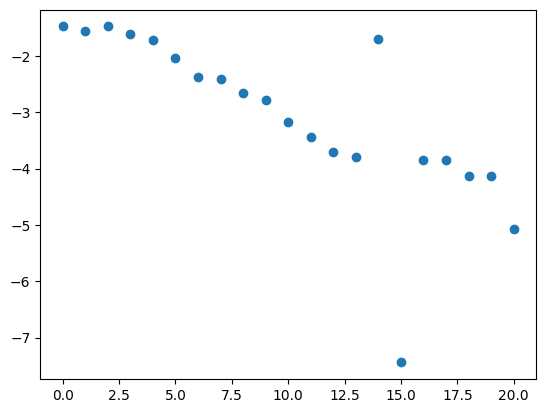

In [8]:
A = np.arange(21)
print(A)
plt.scatter(A, gan['GdB'])

# MANUAL

## Ver graficas completas

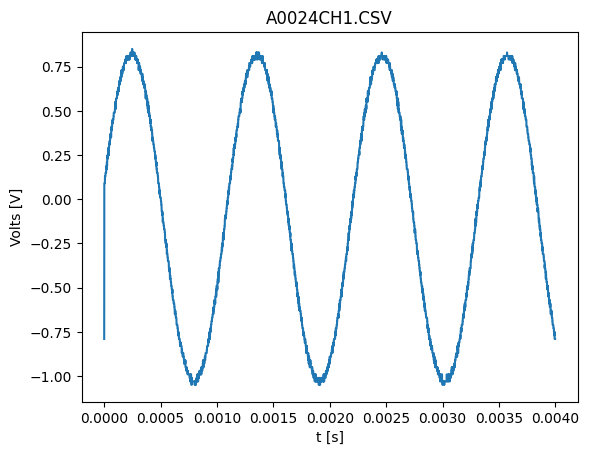

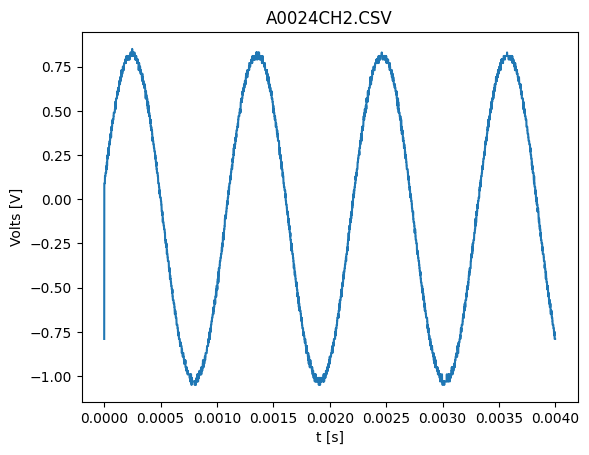

In [48]:
### Testeo
### Selecciona un archivo y muestra la grafica de los 2 canales
### para configurar la mascara
keys = list(fullData.keys())
n = int(input('Numero del archivo (n par): \n').strip())			# Selecciona un archivo

for i in (n, n+1):
	plt.plot(*fullData[keys[n]])
	plt.title(keys[i])
	plt.xlabel('t [s]')
	plt.ylabel('Volts [V]')
	plt.show()

In [24]:
0.2/2.000E-04

1000.0

## Crear mascara
Usa la misma que la grafica

In [13]:
masks = {}

for i in (n,n+1):
	print('Estas enmascarando: ' + keys[i])
	vmin_sug = np.min(fullData[keys[i]][1])
	vmax_sug = np.max(fullData[keys[i]][1])

	print(f'vmin_sug_{i} = ' + str(vmin_sug))
	print(f'vmax_sug_{i} = ' + str(vmax_sug))

	tmin = float(input('tiempo minimo: \n').strip())
	tmax = float(input('tiempo maximo: \n').strip())
	vmin = float(input('voltaje minimo: \n').strip())
	vmax = float(input('voltaje maximo: \n').strip())

	masks[keys[i]] = [tmin, tmax, vmin, vmax]
# print(masks)


Estas enmascarando: A0015CH1.CSV
vmin_sug_26 = -0.89
vmax_sug_26 = 0.69
Estas enmascarando: A0015CH2.CSV
vmin_sug_27 = -0.47000000000000003
vmax_sug_27 = 0.55


## Enmascara

In [16]:
fullDataMask = {}
for key in masks.keys():
	time, d = fullData[key]

	tmink, tmaxk, vmink, vmaxk = masks[key]
	
	mask = (d >= vmink) & (d <= vmaxk) & (time >= tmink) & (time <= tmaxk)

	fullDataMask[key] = [time[mask], d[mask]]


## Grafica con la mascara

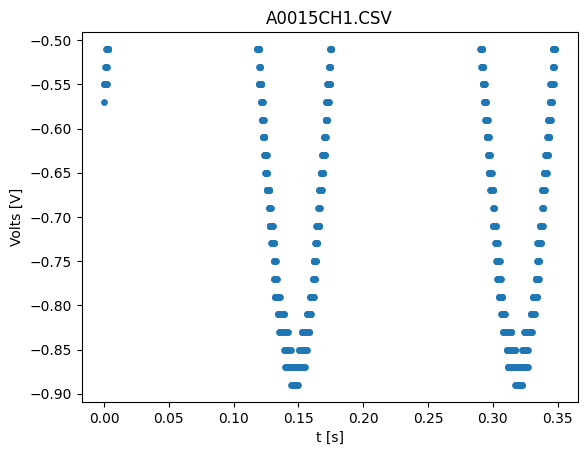

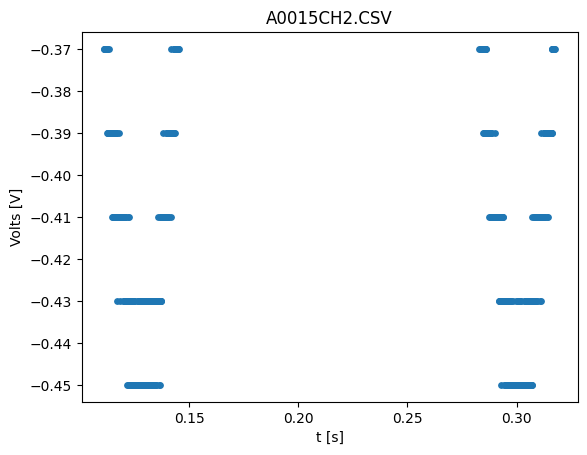

In [17]:
### Selecciona un archivo y muestra la grafica de los 2 canales
### con la mascara aplicada
keys = list(fullData.keys())
n = int(input('Numero del archivo (n) a graficar: \n').strip())			# Selecciona un archivo

t, v = fullDataMask[keys[n]]
plt.scatter(t-fullData[keys[n]][0][0], v, s=15)
plt.title(keys[n])
plt.xlabel('t [s]')
plt.ylabel('Volts [V]')
plt.show()

t, v = fullDataMask[keys[n+1]]
plt.scatter(t-fullData[keys[n+1]][0][0], v, s=15)
plt.title(keys[n+1])
plt.xlabel('t [s]')
plt.ylabel('Volts [V]')
plt.show()

In [ ]:
v1min = float(input('Voltaje min de entrada: \n').strip())
v1max = float(input('Voltaje max de entrada: \n').strip())
v2min = float(input('Voltaje min de salida: \n').strip())
v2max = float(input('Voltaje max de salida: \n').strip())

V1mindB = 20*np.log10(v1min)
V1maxdB = 20*np.log10(v1max)

V2mindB = 20*np.log10(v2min)
V2maxdB = 20*np.log10(v2max)

# Ajuste no lineal

,Vmax,sigma_Vmax,Vinf,sigma_Vinf,tau,sigma_tau
0,5.9862,0.003,0.4893,0.0073,0.9847,0.0027


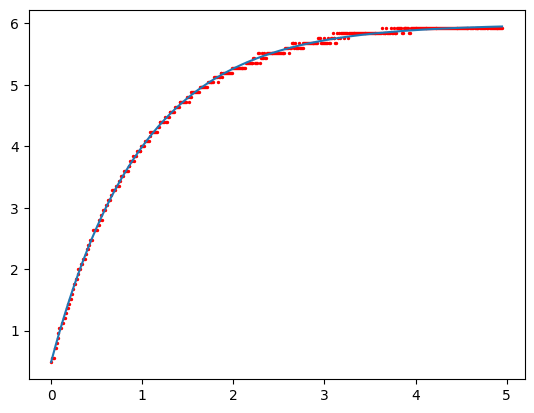

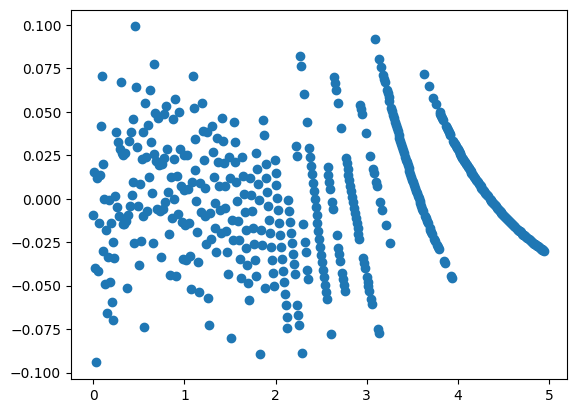

In [ ]:
from scipy.optimize import curve_fit

### Modelo torico de carga
def model(t,Vinf, Vmax, tau):
	return Vmax + (Vinf-Vmax) * np.exp(-t/tau)

### Define una semilla P0
p0 = [data[0], data[-1], 1.0]

### Ajuste con curve_fit, retorna los valores para cada parámetro ajustado popt y
### la matriz de covarianzas
popt, pcov = curve_fit(model, tmask-tmask[0], data[mask], p0=p0)

### Insertidumbre de cada parametro, la raíz de la diagonal
uncertainty = np.sqrt(np.diag(pcov))

### DF para visualizar los parametros y sus insertidunbres
df_valTeo = pd.DataFrame({'Vmax':[np.around(popt[1],4)],'sigma_Vmax':[np.around(uncertainty[1],4)], 'Vinf':[np.around(popt[0],4)],'sigma_Vinf':[np.around(uncertainty[0],4)], 'tau':[np.around(popt[2],4)],'sigma_tau':[np.around(uncertainty[2],4)]})

# print(popt)
display(df_valTeo)


### Grafica ajuste y datos medidos
plt.plot(tmask-tmask[0],model(tmask-tmask[0],*popt))
plt.scatter(tmask-tmask[0],data[mask], c='red', s=2)
plt.show()

### Grafica de residuos para ver confiabilidad de los parametrios ajstados
plt.scatter(tmask-tmask[0],data[mask]-model(tmask-tmask[0], *popt))
plt.show()